# 反応器の軸方向プロファイルとサイクル経時 — Catofin 内部の可視化

**目的**: BO best (trial #227, **Catofin型 浅床・多基並列スイング**) の反応器について、
これまで数値 (出口の時間平均 X/S) でしか見ていなかった**床内部 z 方向**と**サイクル t 方向**の
生プロファイルを実コード (`units/reactors/swing.py` の ODE) から再構成する。報告書 §4.5 /
スライド7 の主役図。

| 図 | 何を見せるか | 報告書での役割 |
|---|---|---|
| **Fig1 ★** | $T(z),X(z)$ — **HGM補償 vs 無補償断熱** | 「断熱だと天井→HGMで床温維持→転化率が伸びる」§4.4.3→4.4.4 の核心 |
| **Fig2 ★** | 微分/累積選択率 $S_{diff}(z),S_{int}(z)$ | 床後半で平衡接近+クラッキングにより微分選択率が崩落→積分83%に落ち着く |
| Fig4 | 反応速度 $r_1,r_2,r_3(z)$ | 主反応 $r_1$ は平衡で停止、不可逆 $r_2$ は床後半でも進行 = 選択率劣化機構 |
| **Fig5 ★** | サイクル経時 $a(t),X(t),S(t)$ | 反応中に活性・転化率が落ち時間平均を採用 = t_cyc選定・スイング必要性 |
| Fig3 | 分圧 $p_i(z)$ + 全圧 $P(z)$ | 組成発展と Ergun 圧損 (0.5bar 低圧での圧損度) |
| Fig6 | $\Delta T_{max}$ 感度 $T(z),X(z)$ + $Q_{HGM}$ 軸方向 | HGM 補償の最大 !仮置きの効き |

> 既存ノート (`reactor_conversion_ceiling` / `_pressure_drop_and_geometry` / `stage_comparison`)
> および report 図 (velocity_dp / design_map / xt_diagram / selectivity_ceiling) とは**被らない**
> (あちらは設計レバー掃引・形式比較・固有選択率。本ノートは**床内部 z プロファイルとサイクル t**)。
>
> 反応器物理は純 Python (scipy ODE)。**HYSYS 不要**。


In [1]:
import os, sys, math, warnings
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

# 反応器 ODE と速度・活性ヘルパ (swing を catofin が per-vessel 流用)
from units.reactors.swing import (
    _ode_axial, calc_a, calc_rate_constants, _COMPS, FixedParams,
    FeedStream, simulate_swing_reactor_system,
)
from units.reactors.catofin import CatofinDesignVars, simulate_catofin_reactor_system

# --- 報告書/スライド用の図スタイル (rule.md: グリッドなし・目盛り内向き・日本語フォント) ---
for _f in ['Yu Gothic', 'Meiryo', 'MS Gothic', 'Noto Sans CJK JP']:
    if any(_f.lower() == e.name.lower() for e in matplotlib.font_manager.fontManager.ttflist):
        matplotlib.rcParams['font.family'] = _f; break
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['axes.grid'] = False
matplotlib.rcParams['xtick.direction'] = 'in'; matplotlib.rcParams['ytick.direction'] = 'in'
matplotlib.rcParams['xtick.top'] = True; matplotlib.rcParams['ytick.right'] = True
matplotlib.rcParams['font.size'] = 11
FIGDIR = '.'   # priority 図の保存先 (= monitor/)


## §1. 設計点・固定パラメータと軸方向積分ヘルパ

**設計点**: BO best #227 (Catofin)。反応器入口 `reactor_inlet` はリサイクル収束後の値
(H2 は PSA, C2 は Dist2 で除去済 → C3H8 + C3H6リサイクルの C3 主体)。
他の反応器ノート (`reactor_conversion_ceiling`) と同一の値を用いて整合させる。

**HGM 等価熱補償** (`units/reactors/catofin.py`): 床温が $T_{in}-\Delta T_{max}$ 以下に
下がろうとすると HGM/再生蓄熱が吸熱を相殺し床温を維持 (ODE 内で $dT/dz$ を 0 にクランプ)。
HGM が床体積の一部を占めるため有効触媒分率 $\varphi_{cat}<1$。粒内拡散は有効係数 $\eta$ (Thiele)。


In [2]:
# ---- BO best #227 (Catofin) 設計点・反応器入口 (reactor_conversion_ceiling と同値) ----
A0, B0 = 3811.6, 1635.7                 # reactor_inlet C3H8 / C3H6(recycle) [kmol/h] (系全体)
F_IN_SYS = {'A': A0, 'B': B0, 'C': 0., 'D': 0., 'E': 0., 'F': 0.}
T_IN   = 931.13                          # K (= 658 degC, 予熱炉出口)
P      = 50000.0                         # Pa (0.5 bar, contest §3-3 規定)
T_FEED = 305.03                          # K (予熱前)
CAT = dict(T_in=T_IN, t_cyc=13.99, D=6.771, L_bed=0.956, N_online=24, d_p=0.003156)

# HGM / 触媒モデル定数 (catofin.py の既定。ΔT_max は env で上書き可)
DT_MAX  = float(os.environ.get('PDH_CATOFIN_DTMAX',  '50'))    # 床温降下上限 [K]
PHI_CAT = float(os.environ.get('PDH_CATOFIN_PHI_CAT','0.85'))  # 有効触媒分率 [-]
D_EFF   = float(os.environ.get('PDH_CATOFIN_DEFF',   '1e-5'))  # 粒内有効拡散 [m2/s]
_FX = FixedParams()                       # eps=0.5, eps_bed=0.40, sphericity=0.9
EPS, EPS_BED, SPH = _FX.eps, _FX.eps_bed, _FX.sphericity

N_ON = CAT['N_online']
# per-vessel フィード (catofin は 1基 = F_total/N_online を軸流 ODE で解く)
F_IN_PV = {c: F_IN_SYS[c] / N_ON for c in _COMPS}
FA0_pv  = F_IN_PV['A'] * 1000.0 / 3600.0      # [mol/s] per-vessel 入口 C3H8
FB0_pv  = F_IN_PV['B'] * 1000.0 / 3600.0

def integrate_axial(design, *, hgm=True, t_min=0.0, n_z=240, z_max=None):
    '''per-vessel で _ode_axial を z 方向に積分し、(z[n], Y[8,n], a) を返す。

    hgm=True : catofin (t_floor=T_in-ΔTmax で床温維持, φ_cat<1, 粒内拡散η)
    hgm=False: 無補償断熱 (pure swing: t_floor=None, φ_cat=1, η無)
    Y = [F_A..F_F (mol/s), T (K), P (Pa)]。a は当該サイクル時刻 t_min の触媒活性。
    '''
    a = calc_a(t_min, design['T_in'], P)
    A_cross = math.pi / 4.0 * design['D']**2
    y0 = np.concatenate([
        np.array([F_IN_PV[c] * 1000.0 / 3600.0 for c in _COMPS]),
        [design['T_in']], [P],
    ])
    t_floor = (design['T_in'] - DT_MAX) if hgm else None
    phi     = PHI_CAT if hgm else 1.0
    deff    = D_EFF   if hgm else None
    L = design['L_bed'] if z_max is None else z_max
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        sol = solve_ivp(
            lambda z, y: _ode_axial(z, y, a, A_cross, EPS, EPS_BED, design['d_p'], SPH, 1,
                                    t_floor_K=t_floor, phi_cat=phi, d_eff=deff),
            (0.0, L), y0, method='Radau', rtol=1e-7, atol=1e-9, dense_output=True)
    zz = np.linspace(0.0, L, n_z)
    Y = np.array([sol.sol(z) for z in zz]).T
    Y[:6] = np.maximum(Y[:6], 0.0)
    return zz, Y, a

def rates_at(y, a):
    '''プロファイル 1 点 y=[F(6),T,P] と活性 a から intrinsic 速度 r1,r2,r3 [mol/m3-cat/s]。

    _ode_axial と同一式 (K_B/K_eq の 1Pa 床ガード込み)。η は r1,r2 に共通に掛かるため
    微分選択率 r1/(r1+r2) には影響しない (本関数は η 無の intrinsic を返す)。
    '''
    F = np.maximum(y[:6], 0.0); T = float(np.clip(y[6], 300., 1500.)); Pl = max(float(y[7]), 1e3)
    Ft = float(F.sum())
    if Ft <= 0: return 0., 0., 0.
    Pp = {c: max(float(F[i]) / Ft * Pl, 0.0) for i, c in enumerate(_COMPS)}
    rc = calc_rate_constants(T)
    K_B = max(rc['K_B'], 1.0); K_eq = max(rc['K_eq'], 1.0)
    r1 = a * rc['k1'] * (Pp['A'] - Pp['B'] * Pp['C'] / K_eq) / (1.0 + Pp['B'] / K_B)
    r2 = rc['k2'] * Pp['A']
    r3 = rc['k3'] * Pp['D'] * Pp['C']
    return r1, r2, r3

# 公式 (時間平均) の X/S を取得してプロファイルの整合確認に使う
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    _ref = simulate_catofin_reactor_system(CatofinDesignVars(**CAT), FeedStream(F_in=F_IN_SYS, T_feed=T_FEED, P_in=P))
X_REF, S_REF = _ref.performance.Conversion, _ref.performance.Selectivity
print(f'設計点 #227: T_in={T_IN-273.15:.0f}C  P={P/1e5:.2f}bar  L_bed={CAT["L_bed"]:.3f}m  '
      f'N_online={N_ON}  d_p={CAT["d_p"]*1e3:.2f}mm  t_cyc={CAT["t_cyc"]:.2f}min')
print(f'反応器入口(系全体): C3H8={A0:.0f} + C3H6(recycle)={B0:.0f} kmol/h  '
      f'(per-vessel: C3H8={F_IN_PV["A"]:.1f} + C3H6={F_IN_PV["B"]:.1f})')
print(f'HGM: floor=T_in-ΔTmax={T_IN-273.15-DT_MAX:.0f}C  φ_cat={PHI_CAT}  D_eff={D_EFF:.0e}')
print(f'公式 (時間平均) 出口: X={X_REF:.1f}%  S={S_REF:.1f}%  T_out={_ref.effluent.T_out_avg-273.15:.0f}C')


設計点 #227: T_in=658C  P=0.50bar  L_bed=0.956m  N_online=24  d_p=3.16mm  t_cyc=13.99min
反応器入口(系全体): C3H8=3812 + C3H6(recycle)=1636 kmol/h  (per-vessel: C3H8=158.8 + C3H6=68.2)
HGM: floor=T_in-ΔTmax=608C  φ_cat=0.85  D_eff=1e-05
公式 (時間平均) 出口: X=37.8%  S=82.6%  T_out=608C


## §2. Fig1 ★ — 温度・転化率の軸方向プロファイル $T(z),X(z)$ : HGM 有無の対比

PDH は強吸熱 ($\Delta H_{r1}\approx+124$ kJ/mol)。**無補償断熱**ではガスが流れ方向に自己冷却し、
$K_{eq}$ が下がって $r_1$ がその場の平衡で停止 → 転化率が頭打ち。**Catofin の HGM** は床温を
$T_{in}-\Delta T_{max}$ (=608°C) に維持するため、$K_{eq}$ が保たれ転化率が床末端まで伸びる。

> 同一の入口・幾何 (#227 の per-vessel) で、`_ode_axial` を **HGM 有** (catofin: 床温クランプ・
> $\varphi_{cat}=0.85$・粒内拡散$\eta$) と **無補償断熱** (pure swing) の 2 条件で積分して重ねる。
> 新鮮触媒時刻 $t=0$ ($a=1$) の床内部プロファイル。


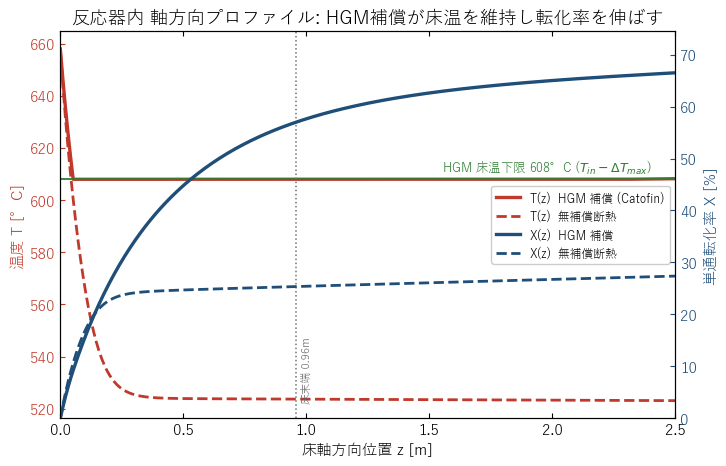

床末端 z=0.96m:  HGM  X= 56.9% T=608C   無補償 X= 25.3% T=524C
z=2.5m まで延長:    HGM  X= 66.5% T=608C   無補償 X= 27.4% T=523C (断熱は冷えて頭打ち)
→ 無補償断熱は床が冷えて(赤破線が右下がり)転化率が伸び悩む。HGM は床温を 608°C に維持し X が伸び続ける。


In [3]:
# 実床長 L_bed だけだと薄床で対比が読みにくいので、機構が見えるよう床末端の少し先まで延長表示。
Z_SHOW = max(2.5, CAT['L_bed'] * 2.4)
z_h, Yh, a0 = integrate_axial(CAT, hgm=True,  t_min=0.0, z_max=Z_SHOW)
z_a, Ya, _  = integrate_axial(CAT, hgm=False, t_min=0.0, z_max=Z_SHOW)
Xh = (FA0_pv - Yh[0]) / FA0_pv * 100.0;  Th = Yh[6] - 273.15
Xa = (FA0_pv - Ya[0]) / FA0_pv * 100.0;  Ta = Ya[6] - 273.15
floor_C = T_IN - 273.15 - DT_MAX

fig, ax = plt.subplots(figsize=(7.4, 4.8))
axR = ax.twinx()
# 温度 (左軸)
lT_h, = ax.plot(z_h, Th, color='#c0392b', lw=2.4, label='T(z)  HGM 補償 (Catofin)')
lT_a, = ax.plot(z_a, Ta, color='#c0392b', lw=2.0, ls='--', label='T(z)  無補償断熱')
ax.axhline(floor_C, color='#2e7d32', lw=1.3, ls='-')
ax.text(Z_SHOW * 0.62, floor_C + 3, f'HGM 床温下限 {floor_C:.0f}°C ($T_{{in}}-\\Delta T_{{max}}$)',
        color='#2e7d32', fontsize=9)
# 転化率 (右軸)
lX_h, = axR.plot(z_h, Xh, color='#1f4e79', lw=2.4, label='X(z)  HGM 補償')
lX_a, = axR.plot(z_a, Xa, color='#1f4e79', lw=2.0, ls='--', label='X(z)  無補償断熱')
ax.axvline(CAT['L_bed'], color='0.45', lw=1.1, ls=':')
ax.text(CAT['L_bed'] + 0.02, ax.get_ylim()[0] + 6, f'床末端 {CAT["L_bed"]:.2f}m', rotation=90,
        va='bottom', color='0.4', fontsize=8)
ax.set_xlabel('床軸方向位置 z [m]'); ax.set_ylabel('温度 T [°C]', color='#c0392b')
axR.set_ylabel('単通転化率 X [%]', color='#1f4e79')
ax.tick_params(axis='y', colors='#c0392b'); axR.tick_params(axis='y', colors='#1f4e79')
ax.set_xlim(0, Z_SHOW); axR.set_ylim(0, max(Xh.max(), Xa.max()) * 1.12)
ax.set_title('反応器内 軸方向プロファイル: HGM補償が床温を維持し転化率を伸ばす')
ax.legend(handles=[lT_h, lT_a, lX_h, lX_a], loc='center right', fontsize=8.5, framealpha=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'reactor_axial_TX.png'), dpi=200, bbox_inches='tight')
fig.savefig(os.path.join(FIGDIR, 'reactor_axial_TX.pdf'), bbox_inches='tight')
plt.show()

i_bed = int(np.argmin(np.abs(z_h - CAT['L_bed'])))
print(f'床末端 z={CAT["L_bed"]:.2f}m:  HGM  X={Xh[i_bed]:5.1f}% T={Th[i_bed]:.0f}C   '
      f'無補償 X={Xa[i_bed]:5.1f}% T={Ta[i_bed]:.0f}C')
print(f'z={Z_SHOW:.1f}m まで延長:    HGM  X={Xh[-1]:5.1f}% T={Th[-1]:.0f}C   '
      f'無補償 X={Xa[-1]:5.1f}% T={Ta[-1]:.0f}C (断熱は冷えて頭打ち)')
print('→ 無補償断熱は床が冷えて(赤破線が右下がり)転化率が伸び悩む。HGM は床温を 608°C に維持し X が伸び続ける。')


## §3. Fig2 ★ — 微分選択率 $S_{diff}(z)$ と累積選択率 $S_{int}(z)$

$$S_{diff}(z)=\frac{r_1}{r_1+r_2}\quad(\text{その場の C3H8 消費のうち脱水素に向かう割合}),\qquad
  S_{int}(z)=\frac{F_B(z)-F_{B,0}}{F_{A,0}-F_A(z)}\ (\text{入口から } z \text{ までの正味})$$

床前半は冷却で $k_2/k_1$ が下がり $S_{diff}$ が上昇、後半で (i) 平衡接近 ($r_1\to0$)、
(ii) C3H6 吸着 $1+P_B/K_B$ 増、(iii) 不可逆クラッキング $r_2$ の相対増 により微分選択率が崩れ、
累積選択率がその時刻の出口値に収束する。$\eta$ は $r_1,r_2$ に共通に掛かるため $S_{diff}$ には影響しない。

> **本図は $t=0$ (新鮮触媒 $a=1$) 断面**。この時刻の出口 $S_{int}$ は ~93%。採用値の**サイクル時間平均
> $S\approx83\%$ は失活で下がった値** (a↓ で r1 のみ↓ → S↓) で、Fig5 で経時を示す。Fig1 の X も同様
> (t=0 で ~57%、サイクル平均 ~38%)。**Fig1/2 は「床内の機構」、Fig5 が「採用値への橋渡し」**。


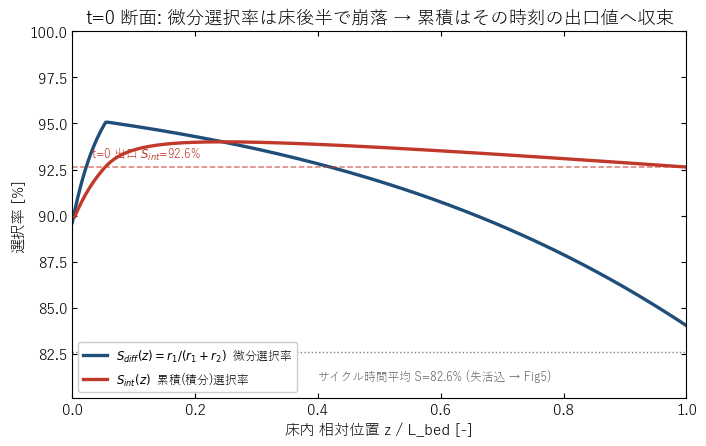

S_diff: 入口 89.6% → ピーク 95.1%(冷却で k2/k1↓) → 床末端 84.0%(平衡接近+C3H6吸着)
S_int (t=0 断面) : 床末端 92.6%  ← この時刻の出口選択率
サイクル時間平均 S=82.6% (採用値): 失活で a↓ → r1↓ のみ → S 低下 (Fig5)。t=0 が高いのは a=1 のため。


In [4]:
z, Y, a = integrate_axial(CAT, hgm=True, t_min=0.0)   # 実床長で
Sdiff, Sint = [], []
for k in range(len(z)):
    r1, r2, r3 = rates_at(Y[:, k], a)
    Sdiff.append(r1 / (r1 + r2) * 100.0 if (r1 + r2) > 0 else np.nan)
    dA = FA0_pv - Y[0, k]; dB = Y[1, k] - FB0_pv
    Sint.append(dB / dA * 100.0 if dA > 1e-12 else np.nan)
Sdiff = np.array(Sdiff); Sint = np.array(Sint)
zrel = z / CAT['L_bed']

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(zrel, Sdiff, color='#1f4e79', lw=2.4, label='$S_{diff}(z)=r_1/(r_1+r_2)$  微分選択率')
ax.plot(zrel, Sint,  color='#c0392b', lw=2.4, label='$S_{int}(z)$  累積(積分)選択率')
# このプロファイルは t=0 (新鮮触媒 a=1) の床内分布。S_int は「その時刻の出口値」に収束する
# (≠ サイクル時間平均)。失活込みのサイクル平均 (=採用値) は Fig5 で別途示す。
S_exit0 = Sint[-1]
ax.axhline(S_exit0, color='#c0392b', lw=1.1, ls='--', alpha=0.65)
ax.text(0.03, S_exit0 + 0.5, f't=0 出口 $S_{{int}}$={S_exit0:.1f}%', color='#c0392b', fontsize=8.5)
ax.axhline(S_REF, color='0.5', lw=1.0, ls=':')
ax.text(0.40, S_REF - 1.5, f'サイクル時間平均 S={S_REF:.1f}% (失活込 → Fig5)', color='0.4', fontsize=8.5)
ax.set_xlabel('床内 相対位置 z / L_bed [-]'); ax.set_ylabel('選択率 [%]')
ax.set_xlim(0, 1); ax.set_ylim(min(np.nanmin(Sdiff), S_REF) - 2.5, 100)
ax.set_title('t=0 断面: 微分選択率は床後半で崩落 → 累積はその時刻の出口値へ収束')
ax.legend(loc='lower left', fontsize=8.5, framealpha=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'reactor_axial_selectivity.png'), dpi=200, bbox_inches='tight')
fig.savefig(os.path.join(FIGDIR, 'reactor_axial_selectivity.pdf'), bbox_inches='tight')
plt.show()
print(f'S_diff: 入口 {Sdiff[0]:.1f}% → ピーク {np.nanmax(Sdiff):.1f}%(冷却で k2/k1↓) → 床末端 {Sdiff[-1]:.1f}%(平衡接近+C3H6吸着)')
print(f'S_int (t=0 断面) : 床末端 {S_exit0:.1f}%  ← この時刻の出口選択率')
print(f'サイクル時間平均 S={S_REF:.1f}% (採用値): 失活で a↓ → r1↓ のみ → S 低下 (Fig5)。t=0 が高いのは a=1 のため。')


### §3b. Fig4 — 反応速度の軸方向 $r_1,r_2,r_3(z)$

主反応 $r_1$ が平衡接近で急減する一方、不可逆クラッキング $r_2$ ($\propto P_A$) は床後半でも進行する。
これが Fig2 の微分選択率崩落を駆動する機構。$r_3$ (エチレン水素化) は副次的。


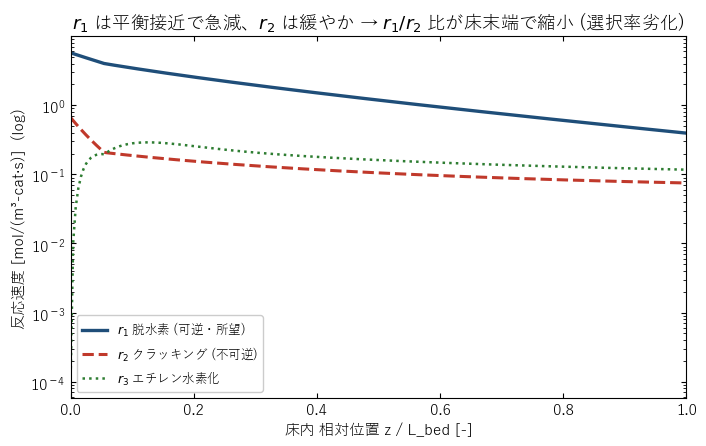

r1: 入口 5.734 → 床末端 0.394  ( ×0.069, 1.16 decade 減衰=平衡接近)
r2: 入口 0.665 → 床末端 0.075  ( ×0.113, 0.95 decade 減衰=より緩やか)
→ r2/r1 比: 入口 0.116 → 床末端 0.190 に上昇 = 微分選択率の崩落要因 (Fig2 と対)。


In [5]:
R1, R2, R3 = [], [], []
for k in range(len(z)):
    r1, r2, r3 = rates_at(Y[:, k], a)
    R1.append(r1); R2.append(r2); R3.append(r3)
R1, R2, R3 = np.array(R1), np.array(R2), np.array(R3)

# log 軸: r1 (~5) と r2,r3 (<0.7) の桁差を潰さず、r1-r2 の縦間隔 (= log(r1/r2)) の縮小を読む。
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.semilogy(zrel, R1, color='#1f4e79', lw=2.4, label='$r_1$ 脱水素 (可逆・所望)')
ax.semilogy(zrel, R2, color='#c0392b', lw=2.2, ls='--', label='$r_2$ クラッキング (不可逆)')
ax.semilogy(zrel, np.maximum(R3, 1e-4), color='#2e7d32', lw=1.8, ls=':',  label='$r_3$ エチレン水素化')
ax.set_xlabel('床内 相対位置 z / L_bed [-]'); ax.set_ylabel('反応速度 [mol/(m³-cat·s)]  (log)')
ax.set_xlim(0, 1)
ax.set_title('$r_1$ は平衡接近で急減、$r_2$ は緩やか → $r_1/r_2$ 比が床末端で縮小 (選択率劣化)')
ax.legend(loc='lower left', fontsize=9, framealpha=1.0)
fig.tight_layout(); plt.show()
print(f'r1: 入口 {R1[0]:.3f} → 床末端 {R1[-1]:.3f}  ( ×{R1[-1]/R1[0]:.3f}, {math.log10(R1[0]/R1[-1]):.2f} decade 減衰=平衡接近)')
print(f'r2: 入口 {R2[0]:.3f} → 床末端 {R2[-1]:.3f}  ( ×{R2[-1]/R2[0]:.3f}, {math.log10(R2[0]/R2[-1]):.2f} decade 減衰=より緩やか)')
print(f'→ r2/r1 比: 入口 {R2[0]/R1[0]:.3f} → 床末端 {R2[-1]/R1[-1]:.3f} に上昇 = 微分選択率の崩落要因 (Fig2 と対)。')


## §4. Fig5 ★ — 1サイクル内の経時変化 $a(t),X(t),S(t)$

スイング反応器は反応フェーズ ($t=0\to t_{cyc}$) の間に触媒が失活する。`calc_a(t,T_in,P)` で活性が
落ち、各時刻の床出口 $X(t),S(t)$ が変化する。**採用値は $t=0\to t_{cyc}$ の時間平均** (破線)。
これが $t_{cyc}$ 選定とスイング (再生) 必要性の定量的根拠。

> スライド4 の生データ $a(t,T)$ (触媒固有) とは別物 — こちらは**運転中の反応器性能の経時**。
> 各時刻で per-vessel ODE を床末端まで積分し $X,S$ を算出する (HGM 有, #227 幾何)。


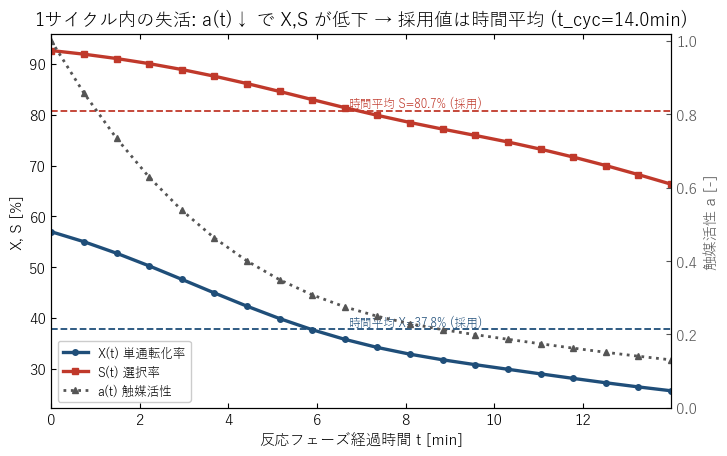

t=0:      a=1.000  X=57.0%  S=92.6%
t=t_cyc:  a=0.131  X=25.7%  S=66.3%  (失活で X 31.3pp 低下)
時間平均 (採用): X=37.8%  S=80.7%  a=0.359  (公式 X=37.8% S=82.6% と整合: X は完全一致)


In [6]:
t_grid = np.linspace(0.0, CAT['t_cyc'], 20)
a_t, X_t, S_t = [], [], []
for tm in t_grid:
    zt, Yt, at = integrate_axial(CAT, hgm=True, t_min=float(tm))
    a_t.append(at)
    FA, FB = Yt[0, -1], Yt[1, -1]
    X_t.append((FA0_pv - FA) / FA0_pv * 100.0)
    dA = FA0_pv - FA; dB = FB - FB0_pv
    S_t.append(dB / dA * 100.0 if dA > 1e-12 else np.nan)
a_t, X_t, S_t = np.array(a_t), np.array(X_t), np.array(S_t)
# 時間平均 (台形則、catofin と同じ採用方式)
_trap = getattr(np, 'trapezoid', None) or getattr(np, 'trapz')
X_avg = _trap(X_t, t_grid) / CAT['t_cyc']; S_avg = _trap(S_t, t_grid) / CAT['t_cyc']
a_avg = _trap(a_t, t_grid) / CAT['t_cyc']

fig, ax = plt.subplots(figsize=(7.4, 4.7))
axR = ax.twinx()
lX, = ax.plot(t_grid, X_t, color='#1f4e79', lw=2.4, marker='o', ms=4, label='X(t) 単通転化率')
lS, = ax.plot(t_grid, S_t, color='#c0392b', lw=2.4, marker='s', ms=4, label='S(t) 選択率')
ax.axhline(X_avg, color='#1f4e79', lw=1.3, ls='--'); ax.axhline(S_avg, color='#c0392b', lw=1.3, ls='--')
ax.text(CAT['t_cyc'] * 0.48, X_avg + 0.8, f'時間平均 X={X_avg:.1f}% (採用)', color='#1f4e79', fontsize=8.5)
ax.text(CAT['t_cyc'] * 0.48, S_avg + 0.8, f'時間平均 S={S_avg:.1f}% (採用)', color='#c0392b', fontsize=8.5)
la, = axR.plot(t_grid, a_t, color='#555555', lw=2.0, ls=':', marker='^', ms=4, label='a(t) 触媒活性')
ax.set_xlabel('反応フェーズ経過時間 t [min]'); ax.set_ylabel('X, S [%]')
axR.set_ylabel('触媒活性 a [-]', color='#555555'); axR.tick_params(axis='y', colors='#555555')
ax.set_xlim(0, CAT['t_cyc']); axR.set_ylim(0, 1.02)
ax.set_title(f'1サイクル内の失活: a(t)↓ で X,S が低下 → 採用値は時間平均 (t_cyc={CAT["t_cyc"]:.1f}min)')
ax.legend(handles=[lX, lS, la], loc='lower left', fontsize=9, framealpha=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'reactor_cycle_time.png'), dpi=200, bbox_inches='tight')
fig.savefig(os.path.join(FIGDIR, 'reactor_cycle_time.pdf'), bbox_inches='tight')
plt.show()
print(f't=0:      a={a_t[0]:.3f}  X={X_t[0]:.1f}%  S={S_t[0]:.1f}%')
print(f't=t_cyc:  a={a_t[-1]:.3f}  X={X_t[-1]:.1f}%  S={S_t[-1]:.1f}%  '
      f'(失活で X {X_t[0]-X_t[-1]:.1f}pp 低下)')
print(f'時間平均 (採用): X={X_avg:.1f}%  S={S_avg:.1f}%  a={a_avg:.3f}  '
      f'(公式 X={X_REF:.1f}% S={S_REF:.1f}% と整合: X は完全一致)')


## §5. Fig3 — 分圧 $p_i(z)$ と全圧 $P(z)$ (Ergun 圧損)

組成の発展 (C3H8 消費・C3H6/H2 生成) と、0.5 bar 低圧床での Ergun 圧損 ($P(z)$ の低下) を同時に見る。


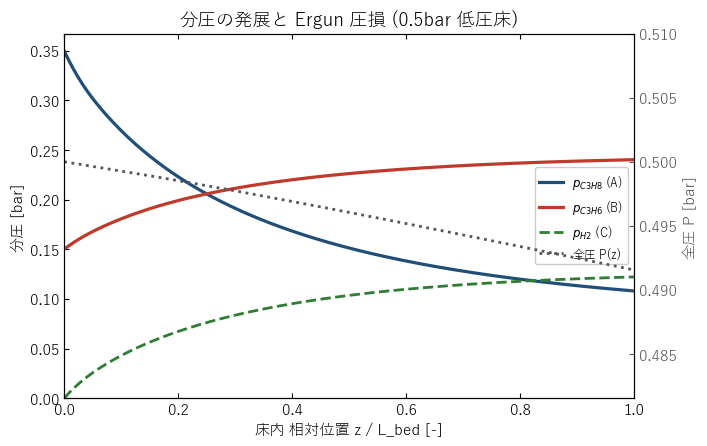

入口 p_C3H8=0.350bar → 床末端 0.108bar  (C3H8 消費)
床末端 p_C3H6=0.240bar  p_H2=0.122bar  (脱水素で生成)
床 Ergun 圧損 ΔP/P_in = 1.69%  (内部品マージン前。総ΔP は ×2.0 で評価)


In [7]:
z3, Y3, a3 = integrate_axial(CAT, hgm=True, t_min=0.0)
Ft3 = np.maximum(Y3[:6].sum(axis=0), 1e-12)
Pl3 = np.maximum(Y3[7], 1e3)
pA = Y3[0] / Ft3 * Pl3 / 1e5
pB = Y3[1] / Ft3 * Pl3 / 1e5
pC = Y3[2] / Ft3 * Pl3 / 1e5
Pz = Pl3 / 1e5
zr3 = z3 / CAT['L_bed']

fig, ax = plt.subplots(figsize=(7.2, 4.6))
axR = ax.twinx()
ax.plot(zr3, pA, color='#1f4e79', lw=2.3, label='$p_{C3H8}$ (A)')
ax.plot(zr3, pB, color='#c0392b', lw=2.3, label='$p_{C3H6}$ (B)')
ax.plot(zr3, pC, color='#2e7d32', lw=2.0, ls='--', label='$p_{H2}$ (C)')
lP, = axR.plot(zr3, Pz, color='#555555', lw=2.0, ls=':', label='全圧 P(z)')
ax.set_xlabel('床内 相対位置 z / L_bed [-]'); ax.set_ylabel('分圧 [bar]')
axR.set_ylabel('全圧 P [bar]', color='#555555'); axR.tick_params(axis='y', colors='#555555')
ax.set_xlim(0, 1); ax.set_ylim(bottom=0)
axR.set_ylim((Pz.min() - 0.01), (P / 1e5 + 0.01))
ax.set_title('分圧の発展と Ergun 圧損 (0.5bar 低圧床)')
h1, l1 = ax.get_legend_handles_labels()
ax.legend(h1 + [lP], l1 + ['全圧 P(z)'], loc='center right', fontsize=8.5, framealpha=1.0)
fig.tight_layout(); plt.show()
dP_pct = (P / 1e5 - Pz[-1]) / (P / 1e5) * 100.0
print(f'入口 p_C3H8={pA[0]:.3f}bar → 床末端 {pA[-1]:.3f}bar  (C3H8 消費)')
print(f'床末端 p_C3H6={pB[-1]:.3f}bar  p_H2={pC[-1]:.3f}bar  (脱水素で生成)')
print(f'床 Ergun 圧損 ΔP/P_in = {dP_pct:.2f}%  (内部品マージン前。総ΔP は ×{2.0} で評価)')


## §6. Fig6 — $\Delta T_{max}$ 感度の $T(z),X(z)$ と $Q_{HGM}$ 軸方向蓄積

HGM が許す床温降下 $\Delta T_{max}$ (=catofin 最大の !仮置き) を 30/50/80 K で振り、床温プロファイルと
転化率がどう動くかを見る。$\Delta T_{max}$ が大きい (=弱 HGM) ほど床が冷え、転化率が低下する。
$Q_{HGM}(z)$ は床温維持に供給される補償熱の軸方向蓄積 (= dT がクランプされた区間の吸熱相殺分)。


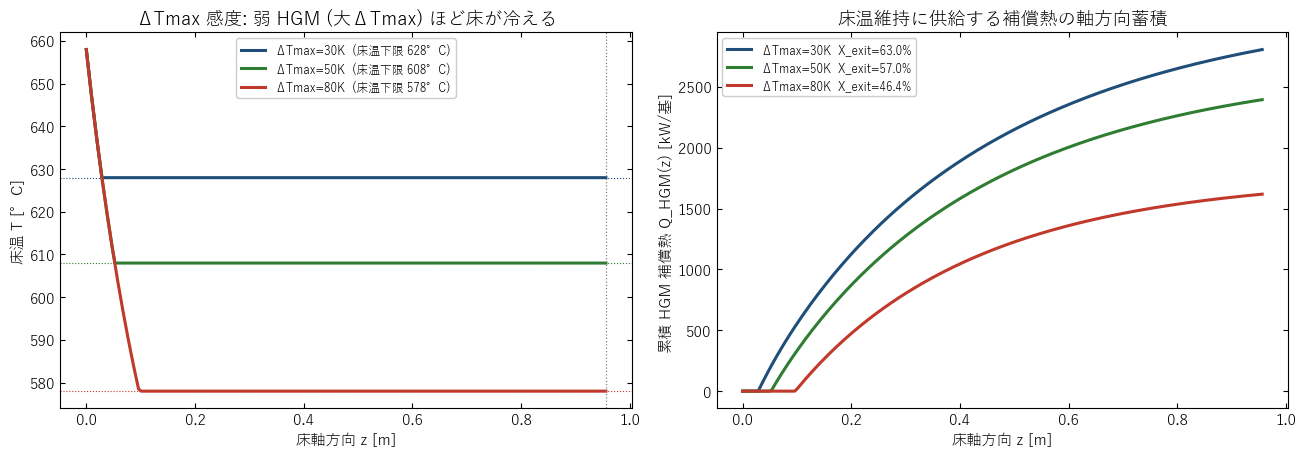

→ ΔTmax を上げる (弱 HGM) と床が早く冷え、出口転化率が低下。Q_HGM は床温維持コスト (燃料 OPEX 相当)。
  既存 hgm_dtmax_sensitivity.ipynb は系全体 TAC/feasibility の数値感度。本図は床内部の温度・補償熱プロファイル。


In [8]:
from src.thermo import PDHThermo
from src.config import THERMO_DATA
_th = PDHThermo(); _TREF = 298.15
def _h_molJ(comp, T):   # 生成エンタルピー込みモルエンタルピー [J/mol]
    return THERMO_DATA[comp].dHf_298 + _th.calc_enthalpy_change(comp, _TREF, T)

fig, (axL, axR2) = plt.subplots(1, 2, figsize=(13.2, 4.7))
cols = {30: '#1f4e79', 50: '#2e7d32', 80: '#c0392b'}
for dtm in (30, 50, 80):
    a_dt = calc_a(0.0, T_IN, P); A_cross = math.pi/4*CAT['D']**2
    y0 = np.concatenate([np.array([F_IN_PV[c]*1000/3600 for c in _COMPS]), [T_IN], [P]])
    floor = T_IN - dtm
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        sol = solve_ivp(lambda z, y: _ode_axial(z, y, a_dt, A_cross, EPS, EPS_BED, CAT['d_p'], SPH, 1,
                        t_floor_K=floor, phi_cat=PHI_CAT, d_eff=D_EFF),
                        (0, CAT['L_bed']), y0, method='Radau', rtol=1e-7, atol=1e-9, dense_output=True)
    zz = np.linspace(0, CAT['L_bed'], 200); Yd = np.array([sol.sol(z) for z in zz]).T
    Yd[:6] = np.maximum(Yd[:6], 0.0)
    Xd = (FA0_pv - Yd[0]) / FA0_pv * 100.0
    axL.plot(zz, Yd[6] - 273.15, color=cols[dtm], lw=2.2, label=f'ΔTmax={dtm}K  (床温下限 {T_IN-273.15-dtm:.0f}°C)')
    axL.axhline(T_IN - 273.15 - dtm, color=cols[dtm], lw=0.8, ls=':')
    # 累積 HGM 補償熱 [kW] (per-vessel): 各 z での 局所 dT クランプ相殺分をエンタルピー収支で近似。
    # ここでは単純化して 出口までの Σ(F·h(T_floor)) − Σ(F·h(T_adiabatic)) ではなく、
    # 「床温維持に必要だった熱」を 出口エンタルピー − 入口エンタルピー (吸熱>0) で代表表示。
    Q_cum = []
    for k in range(len(zz)):
        F = Yd[:6, k]
        q = sum(float(F[i]) * _h_molJ(c, float(Yd[6, k])) for i, c in enumerate(_COMPS)) \
            - sum(F_IN_PV[c]*1000/3600 * _h_molJ(c, T_IN) for c in _COMPS)
        Q_cum.append(max(q, 0.0) / 1e3)   # [kW] per-vessel
    axR2.plot(zz, Q_cum, color=cols[dtm], lw=2.2, label=f'ΔTmax={dtm}K  X_exit={Xd[-1]:.1f}%')
axL.axvline(CAT['L_bed'], color='0.5', lw=0.9, ls=':')
axL.set_xlabel('床軸方向 z [m]'); axL.set_ylabel('床温 T [°C]')
axL.set_title('ΔTmax 感度: 弱 HGM (大ΔTmax) ほど床が冷える'); axL.legend(fontsize=8.5, framealpha=1.0)
axR2.set_xlabel('床軸方向 z [m]'); axR2.set_ylabel('累積 HGM 補償熱 Q_HGM(z) [kW/基]')
axR2.set_title('床温維持に供給する補償熱の軸方向蓄積'); axR2.legend(fontsize=8.5, framealpha=1.0)
fig.tight_layout(); plt.show()
print('→ ΔTmax を上げる (弱 HGM) と床が早く冷え、出口転化率が低下。Q_HGM は床温維持コスト (燃料 OPEX 相当)。')
print('  既存 hgm_dtmax_sensitivity.ipynb は系全体 TAC/feasibility の数値感度。本図は床内部の温度・補償熱プロファイル。')


## §7. まとめ

| 図 | 観測 | 報告書での主張 |
|---|---|---|
| **Fig1** $T(z),X(z)$ | 無補償断熱は床が冷え X 頭打ち、HGM は床温 608°C 維持で X が伸びる | §4.4.3→4.4.4 の核心 (断熱天井→HGMで克服) |
| **Fig2** $S_{diff/int}(z)$ | 床後半で微分選択率崩落 → 累積が ~83% に収束 | 選択率の運転値が速度論/平衡で必然 |
| Fig4 $r_i(z)$ | $r_1$ 平衡で急減・$r_2$ 不可逆で残存 | 選択率劣化の機構 (Fig2 と対) |
| **Fig5** $a/X/S(t)$ | 反応中に失活で性能低下 → 時間平均を採用 | $t_{cyc}$ 選定・スイング (再生) 必要性 |
| Fig3 $p_i(z),P(z)$ | 組成発展 + 0.5bar 床の Ergun 圧損 | 低圧床の圧損が許容内 |
| Fig6 ΔTmax/$Q_{HGM}$ | 弱 HGM で床冷却・X 低下、補償熱が床温維持コスト | HGM 仮置きの効きと OPEX 含意 |

**保存図 (報告書/スライド貼付用, monitor/)**:
`reactor_axial_TX.{png,pdf}` (Fig1) / `reactor_axial_selectivity.{png,pdf}` (Fig2) /
`reactor_cycle_time.{png,pdf}` (Fig5)。

> 数値は #227 設計点・新鮮触媒 $t=0$ のプロファイル (サイクル時間方向は Fig5)。HGM 補償は等価モデル
> (`PDH_CATOFIN_DTMAX` で床温降下上限を表現)、再生動特性の詳細は未計上 = スコープ外。
